# Monitor — AVIDa-hIL6 acquisition

Downloads **AVIDa-hIL6** into `data/raw/` and reduces it to the four antigens of
the working set. Nothing else: preprocessing (expression-wrapper stripping,
mutation parsing, flip-set extraction) happens downstream.

Source: `COGNANO/AVIDa-hIL6` on HuggingFace (DOI 10.57967/hf/4241),
paper arXiv:2306.03329 (NeurIPS 2023 D&B), code github.com/cognano/AVIDa-hIL6.
**Licence CC BY-NC 4.0** — non-commercial only; state this in any writeup.

Plain HTTPS, no token and no `huggingface_hub` dependency. The documented
`load_dataset("COGNANO/AVIDa-hIL6")` route raises `DatasetGenerationCastError`:
the two CSVs have mismatched schemas and are not declared as separate configs.

| file | size | contents |
|---|---|---|
| `AVIDa-hIL6.csv` | 104.7 MB | 573,891 VHH/antigen pairs, binary labels |
| `antigen_sequences.csv` | 7.1 kB | 31 antigens: IL-6 WT + 30 point mutants |

> Note: sequences in both files carry expression wrappers (VHH: 22-residue
> phagemid signal peptide + His6; antigen: IL-6 precursor signal peptide
> P05231 1–29 + His6). They are left intact here — strip them before any
> structure prediction or MD.

## 0. Configuration

In [1]:
import hashlib
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import average_precision_score

WD  = Path("/Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations")
RAW = WD / "data" / "raw"
PRO = WD / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PRO.mkdir(parents=True, exist_ok=True)

REPO = "https://huggingface.co/datasets/COGNANO/AVIDa-hIL6/resolve/main"
FILES = {
    "AVIDa-hIL6.csv":        104_655_792,
    "antigen_sequences.csv":       7_133,
}

# Prediction methods: directory name -> display name. Model files live at
# <dir>/<target>/output/models/ (AF3, Protenix_v2, OpenDDE) or <dir>/<target>/models/
# (ESMFold2); both layouts are handled where they are read.
MODELS = {"AF3": "AF3", "ESMFold2": "ESMFold2",
          "Protenix_v2": "Protenix-v2", "OpenDDE": "OpenDDE"}

# Residues trimmed from the N-terminus of the mature target before writing
# targets.csv. Mature IL-6 1-17 is disordered (no coordinates in 1P9M chain B),
# a flexible arm that would wander into the funnel exit cone in MD. 0 disables.
TRIM_N_TERM = 20

## 1. Download

Streamed, with a size check so a re-run is a no-op. A file present at the wrong
size is re-fetched — a truncated 105 MB CSV otherwise fails much later and much
less obviously.

In [2]:
def fetch(name, expect_bytes, chunk=1 << 20):
    dest = RAW / name
    if dest.exists() and dest.stat().st_size == expect_bytes:
        print(f"{name:24s} cached  ({dest.stat().st_size:,} B)")
        return dest
    if dest.exists():
        print(f"{name:24s} size mismatch "
              f"({dest.stat().st_size:,} != {expect_bytes:,}) -> refetching")
    tmp, got = dest.with_suffix(dest.suffix + ".part"), 0
    with urllib.request.urlopen(f"{REPO}/{name}", timeout=120) as r, open(tmp, "wb") as fh:
        while True:
            buf = r.read(chunk)
            if not buf:
                break
            fh.write(buf)
            got += len(buf)
            if got % (1 << 24) < chunk:
                print(f"  {name} {got/1e6:7.1f} / {expect_bytes/1e6:.1f} MB")
    print(f"{name:24s} done    ({got:,} B)")
    assert got == expect_bytes, f"{name}: got {got:,} B, expected {expect_bytes:,} B"
    tmp.rename(dest)
    return dest


paths = {n: fetch(n, sz) for n, sz in FILES.items()}

for n, p in paths.items():
    print(f"{n:24s} sha256 {hashlib.sha256(p.read_bytes()).hexdigest()}")

AVIDa-hIL6.csv           cached  (104,655,792 B)
antigen_sequences.csv    cached  (7,133 B)
AVIDa-hIL6.csv           sha256 917d90f111d759edc3440f577458d42ef89ff0315b186d6c266c120143b20cde
antigen_sequences.csv    sha256 8f023581932e626ba1e2da4f7f861b998b8fcb7516aedb785d831f8c36984e68


## 2. Reduce to the working set

Four antigens: WT IL-6 plus the three alanine mutants chosen as the FMD panel.
Each sits at a receptor interface in 1P9M (biological assembly) and is
solvent-exposed, so a loss of VHH binding there is plausibly a contact effect,
not a folding effect.

| antigen | mature | binds | partner domain | site | buried |
|---|---|---|---|---|---|
| `IL-6_F102A` | F73  | IL-6Ra | D2/D3 (CBM) | I  | 71 A^2 |
| `IL-6_E138A` | E109 | gp130  | D2 (CBM)    | II | 82 A^2 |
| `IL-6_F153A` | F124 | gp130  | D2 (CBM)    | II | 33 A^2 |

`IL-6_F102A` is additionally contacted by three camelid binders (VHH6 in 5FUC,
Fab 61H7 in 4O9H, Fab 68F2 in 4ZS7), making it the best-evidenced position in
the whole 30-position scan.

Mutation labels are in **precursor** numbering (the frame of the `Ag_sequence`
strings); mature = label - 29.

In [3]:
pairs = pd.read_csv(paths["AVIDa-hIL6.csv"])
ags   = pd.read_csv(paths["antigen_sequences.csv"])
print(f"loaded {len(pairs):,} pairs, {len(ags)} antigens")

TARGETS = ["IL-6_WTs", "IL-6_F102A", "IL-6_E138A", "IL-6_F153A"]

# Output naming. The release calls wild type "IL-6_WTs" (plural: constants.py in
# the AVIDa repo defines WT-1/WT-2/WT-3, pooled into one label here). Written
# files use the simpler "IL-6_WT"; every lookup against the release keeps the
# original label.
OUT_NAME = {"IL-6_WTs": "IL-6_WT"}
out_name = lambda t: OUT_NAME.get(t, t)

missing = set(TARGETS) - set(ags.Ag_label)
assert not missing, f"target antigens absent from the release: {missing}"

sub = pairs[pairs.Ag_label.isin(TARGETS)].copy()

counts = (sub.groupby("Ag_label")
             .agg(pairs=("label", "size"),
                  binders=("label", "sum"),
                  unique_VHH=("VHH_sequence", "nunique"))
             .assign(non_binders=lambda d: d.pairs - d.binders,
                     pct_binder=lambda d: (d.binders / d.pairs * 100).round(2))
             .loc[TARGETS, ["pairs", "binders", "non_binders", "pct_binder", "unique_VHH"]])

print(counts.to_string())
print(f"\nTOTAL  pairs {len(sub):,}   binders {int(sub.label.sum()):,}   "
      f"non-binders {len(sub) - int(sub.label.sum()):,}   "
      f"({sub.label.mean():.2%} positive)")
print(f"unique VHH sequences across the four targets: {sub.VHH_sequence.nunique():,}")

# how many VHHs were assayed against how many of the four
cov = sub.groupby("VHH_sequence").Ag_label.nunique().value_counts().sort_index()
print("\nVHHs by number of the four targets they were tested on:")
print(cov.rename_axis("n_targets").to_frame("n_VHH").to_string())

PRO = WD / "data" / "processed"
PRO.mkdir(parents=True, exist_ok=True)
sub.to_csv(PRO / "subset_4targets.csv", index=False)
print(f"\nwrote {PRO / 'subset_4targets.csv'}  ({len(sub):,} rows)")

loaded 573,891 pairs, 31 antigens
            pairs  binders  non_binders  pct_binder  unique_VHH
Ag_label                                                       
IL-6_WTs    13020      540        12480        4.15       13020
IL-6_F102A  24040      615        23425        2.56       24040
IL-6_E138A  10974     1402         9572       12.78       10974
IL-6_F153A  11469     1158        10311       10.10       11469

TOTAL  pairs 59,503   binders 3,715   non-binders 55,788   (6.24% positive)
unique VHH sequences across the four targets: 26,776

VHHs by number of the four targets they were tested on:
           n_VHH
n_targets       
1          10817
2           5226
3           4698
4           6035

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/data/processed/subset_4targets.csv  (59,503 rows)


## 3. Clonotype clustering (full repertoire)

Assigns every VHH in the release to a **clonotype** — a set of sequences
descended from one founder B cell. Two VHHs in the same clonotype are one
evolutionary experiment sampled twice, so they are *not* independent evidence
and must not be counted as separate systems downstream.

Run on the **whole release**, not on any subset: single-linkage cluster
membership depends on which sequences are present, so clustering a subset
inflates apparent independence. Computing it once here means every downstream
selection just joins on `clonotype`.

**Why not whole-sequence identity.** A VHH is a germline scaffold with three
hypervariable loops. Framework is ~85% of the domain and is near-identical
across *all* VHHs from one animal, related or not — measured on this repertoire,
random unrelated pairs are already **66% identical** (90th pct 74%). An 80%
whole-domain threshold therefore sits in the noise. CDR3 is the VDJ junction and
has no such floor: random pairs share **16%** (90th pct 30%), so an 80% CDR3
threshold is ~50 points clear of the null.

**Definition used here:** same CDR3 length + >= 80% CDR3 identity (positionwise,
no alignment needed since lengths match), single-linkage.

> Caveat: this is CDR3-only. The full clonotype definition also requires the same
> **V and J germline genes**, which needs ANARCI or IgBLAST with camelid
> (*Vicugna pacos*) germlines. Adding V/J can only *split* clonotypes, never merge
> them, so the counts here are a **lower bound** on independence.
>
> CDR3 is located by regex rather than IMGT numbering and parses ~85% of domains;
> the rest stay singletons. Good enough for counting independence, not for a
> figure.

In [4]:
import re

VHH_SIGNAL = "MKYLLPTAAAGLLLLAAQPAMA"      # 22 aa phagemid signal peptide
CDR3_TH    = 0.80                          # CDR3 identity threshold

# Domain = raw sequence minus the fixed-length signal peptide and the His tag.
# Sliced by length, not prefix-matched: ~1.4% of entries carry point mutations
# inside the signal peptide and would otherwise keep the whole wrapper.
dom = (pd.Series(pairs.VHH_sequence.unique())
         .str[len(VHH_SIGNAL):]
         .str.replace(r"H+$", "", regex=True)
         .drop_duplicates()
         .reset_index(drop=True))
print(f"unique VHH domains in the release: {len(dom):,}")

_START = re.compile(r"[YFH][YFVAHL][CG]")   # end of FR3 (…YYC / …YFC / …HYG)
_END   = re.compile(r"WG.G")                # start of FR4 (WGQG / WGKG …)

def cdr3(s):
    a = list(_START.finditer(s)); b = list(_END.finditer(s))
    if not a or not b:
        return None
    i, j = a[-1].end(), b[-1].start()
    return s[i:j] if 2 < j - i < 45 else None

clo = pd.DataFrame({"VHH_domain": dom, "cdr3": dom.map(cdr3)})
print(f"CDR3 parsed: {clo.cdr3.notna().sum():,} ({clo.cdr3.notna().mean():.1%}) "
      f"— unparsed stay singletons")

# union-find over (equal CDR3 length) blocks, vectorised Hamming
parent = np.arange(len(clo))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x

ok = clo[clo.cdr3.notna()]
for L, g in ok.groupby(ok.cdr3.str.len()):
    idx = g.index.to_numpy()
    M = np.frombuffer("".join(g.cdr3).encode(), dtype=np.uint8).reshape(len(g), L)
    need = int(np.ceil(CDR3_TH * L))
    step = max(1, int(4e7 // (len(g) * L)))
    for i in range(0, len(g), step):
        eq = (M[i:i + step, None, :] == M[None, :, :]).sum(2)
        for r, c in zip(*np.nonzero(eq >= need)):
            a, b = idx[i + r], idx[c]
            if a < b:
                ra, rb = find(a), find(b)
                if ra != rb:
                    parent[rb] = ra

clo["clonotype"] = [find(i) for i in range(len(clo))]
sizes = clo.clonotype.value_counts()
print(f"\n{len(clo):,} domains  ->  {clo.clonotype.nunique():,} clonotypes")
print(f"  singletons {int((sizes == 1).sum()):,}   largest {int(sizes.max()):,}")
print("\nclonotype size distribution (head):")
print(sizes.value_counts().sort_index().head(8)
           .rename_axis("size").to_frame("n_clonotypes").to_string())

clo.to_csv(PRO / "clonotypes.csv", index=False)
print(f"\nwrote {PRO / 'clonotypes.csv'}  ({len(clo):,} rows)")

unique VHH domains in the release: 38,109
CDR3 parsed: 32,195 (84.5%) — unparsed stay singletons



38,109 domains  ->  17,212 clonotypes
  singletons 14,723   largest 2,647

clonotype size distribution (head):
      n_clonotypes
size              
1            14723
2             1262
3              353
4              206
5              119
6               82
7               76
8               54

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/data/processed/clonotypes.csv  (38,109 rows)


## 4. Flip-pair extraction

A **flip pair** is one VHH assayed against two antigens with *opposite* labels:

```
VHH #4821   IL-6_WTs  -> binder        IL-6_F102A -> non-binder
```

The VHH is byte-identical on both sides, so the only difference is a single
alanine substitution on the antigen. Whatever separates binder from non-binder
has to come from that one side chain — which is the causal handle the whole
benchmark rests on. Two useful consequences:

* **Balance for free.** Each pair contributes exactly one binder and one
  non-binder, despite the raw data being ~26:1.
* **No docking asymmetry.** The mutant complex is built by mutating one residue
  *in the WT bound pose*, so neither side needs a docking step that could
  correlate with the label.

**Order matters, and it is not clonotype-first.** Flips are defined on *exact*
VHH identity; clonotypes from section 3 are joined on afterwards, only to count
independence. Defining flips at clonotype level would compare *different* VHHs
and destroy the pairing.

Two directions are recorded. `lose` (binds WT, fails on the mutant) is the
mechanistically interpretable one. `gain` is reported but is a poor FMD target:
an alanine substitution *creating* a binder is not a mechanism these simulations
have reason to capture.

> The count that matters downstream is **independent clonotypes**, not pairs.
> Pairs within one clonotype are one lineage sampled repeatedly; any panel
> selection, bootstrap or CI must be taken over clonotypes.

In [5]:
WT = "IL-6_WTs"
MUTANTS = [t for t in TARGETS if t != WT]

# Domain-level identity: two raw sequences differing only in the signal peptide
# are the same binder, so collapse to the domain before pairing.
f = sub.copy()
f["VHH_domain"] = (f.VHH_sequence.str[len(VHH_SIGNAL):]
                    .str.replace(r"H+$", "", regex=True))

# Drop truncated domains. A complete VHH is ~111-132 aa (1st-99th pct of this
# release, median 124); 0.4% fall below 110 and are deletion/chimera artifacts
# from read assembly, missing CDR1 + FR2 + CDR2 entirely. They cannot fold into
# an Ig domain, so any structure predicted for them is fiction and MD on them is
# meaningless. Lower bound only: long domains are legitimate (camelid CDR3s run
# long, max here 151), it is the short tail that is artefactual.
MIN_DOMAIN_LEN = 110
short = f.VHH_domain.str.len() < MIN_DOMAIN_LEN
print(f"truncated domains dropped (<{MIN_DOMAIN_LEN} aa): "
      f"{f.loc[short, 'VHH_domain'].nunique()} domains, {int(short.sum())} rows")
f = f[~short]

# Drop any (domain, antigen) assayed with contradictory labels.
bad = (f.groupby(["VHH_domain", "Ag_label"]).label.nunique().loc[lambda s: s > 1])
print(f"(domain, antigen) combinations with contradictory labels: {len(bad):,}")
if len(bad):
    key = set(bad.index)
    f = f[~pd.MultiIndex.from_arrays([f.VHH_domain, f.Ag_label]).isin(key)]

tab = f.pivot_table(index="VHH_domain", columns="Ag_label",
                    values="label", aggfunc="max")

rows = []
for m in MUTANTS:
    both = tab[[WT, m]].dropna()
    for dom_, (w, mu) in both.iterrows():
        if w != mu:
            rows.append(dict(VHH_domain=dom_, mutant=m,
                             direction="lose" if w == 1 else "gain",
                             label_WT=int(w), label_mutant=int(mu)))
flips = pd.DataFrame(rows)

# Join the section-3 clonotypes. Independence is counted on these, not on rows.
flips = flips.merge(clo[["VHH_domain", "clonotype", "cdr3"]],
                    on="VHH_domain", how="left", validate="many_to_one")
assert flips.clonotype.notna().all(), "flip VHH missing from the clonotype table"

print(f"\nflip pairs {len(flips)}   distinct VHH domains {flips.VHH_domain.nunique()}"
      f"   distinct clonotypes {flips.clonotype.nunique()}")

summary = (flips.groupby(["mutant", "direction"])
                .agg(pairs=("VHH_domain", "size"),
                     domains=("VHH_domain", "nunique"),
                     clonotypes=("clonotype", "nunique")))
print("\n" + summary.to_string())

loss = flips[flips.direction == "lose"]
print(f"\nLOSS direction: {len(loss)} pairs -> {loss.VHH_domain.nunique()} domains "
      f"-> {loss.clonotype.nunique()} INDEPENDENT CLONOTYPES")
print("\nclonotypes available per mutant (loss):")
for m in MUTANTS:
    cs = sorted(int(x) for x in loss.loc[loss.mutant == m, "clonotype"].unique())
    print(f"  {m:<12} ({len(cs):>2}) {cs}")

flips.to_csv(PRO / "flip_pairs.csv", index=False)
print(f"\nwrote {PRO / 'flip_pairs.csv'}  ({len(flips)} rows)")

# ---------------------------------------------------------------------------
# Collapsed view: one row per (clonotype, mutant, direction) — the unit a panel
# is selected on, since pairs within a clonotype are one lineage sampled twice.
# The representative VHH is the lexicographically first domain in the clonotype:
# arbitrary but deterministic. There are no read counts in the release, so there
# is no "most abundant member" to prefer.
# ONE representative per clonotype, not per (clonotype, mutant): the member
# assayed in the most of that clonotype's (mutant, direction) rows, ties broken
# lexicographically so the choice is deterministic. Picking per-mutant would hand
# the same lineage different sequences for different mutants for no reason.
rep_of = {}
for c_, g in flips.groupby("clonotype"):
    rows = set(zip(g.mutant, g.direction))
    cover = {d: set(zip(gg.mutant, gg.direction)) for d, gg in g.groupby("VHH_domain")}
    best = max(sorted(cover), key=lambda d: len(cover[d]))
    # The representative must itself have been assayed in every row it is used
    # for, otherwise we would assert a flip that was never measured.
    assert cover[best] == rows, f"clonotype {c_}: no member covers all its rows"
    rep_of[c_] = best

cdr3_of = dict(zip(flips.VHH_domain, flips.cdr3))
by_clono = (flips.groupby(["clonotype", "mutant", "direction"])
                 .agg(n_pairs=("VHH_domain", "size"),
                      n_domains=("VHH_domain", "nunique"))
                 .reset_index())
by_clono["rep_VHH_domain"] = by_clono.clonotype.map(rep_of)
by_clono["rep_cdr3"] = by_clono.rep_VHH_domain.map(cdr3_of)
by_clono = by_clono.sort_values(["direction", "mutant", "clonotype"])
assert by_clono.rep_VHH_domain.nunique() == flips.clonotype.nunique(), \
    "one representative per clonotype expected"

by_clono.to_csv(PRO / "flip_pairs_clonotypes.csv", index=False)
print(f"wrote {PRO / 'flip_pairs_clonotypes.csv'}  ({len(by_clono)} rows)")

print(f"\ncollapsed: {len(flips)} pairs -> {len(by_clono)} (clonotype, mutant, direction) rows")
by_clono

truncated domains dropped (<110 aa): 99 domains, 217 rows
(domain, antigen) combinations with contradictory labels: 3



flip pairs 34   distinct VHH domains 19   distinct clonotypes 17

                      pairs  domains  clonotypes
mutant     direction                            
IL-6_E138A gain           4        4           3
           lose           8        8           8
IL-6_F102A gain           2        2           2
           lose          10       10           9
IL-6_F153A gain           2        2           2
           lose           8        8           8

LOSS direction: 26 pairs -> 12 domains -> 11 INDEPENDENT CLONOTYPES

clonotypes available per mutant (loss):
  IL-6_F102A   ( 9) [25, 30, 50, 53, 101, 110, 201, 490, 12476]
  IL-6_E138A   ( 8) [25, 30, 50, 53, 83, 201, 505, 12476]
  IL-6_F153A   ( 8) [30, 50, 53, 83, 110, 201, 505, 12476]

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/data/processed/flip_pairs.csv  (34 rows)
wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/data/processed/flip_pairs_clonotypes.csv  (3

,clonotype,mutant,direction,n_pairs,n_domains,rep_VHH_domain,rep_cdr3
0,1,IL-6_E138A,gain,2,2,QVQLQESGGGLVQPGGSLRLSCAASGFTLDYYNIGWFRQAPGKERK...,AADRCPDPCSLATTPLSGREYDY
19,145,IL-6_E138A,gain,1,1,QVQLQESGGGSVQVGGSLSLSCVVSGRAISNYAMGWFRQALGAERE...,ASTRRGIMREEYYAY
27,1226,IL-6_E138A,gain,1,1,QVQLQESGGGLVQAGGSLRLSCAASGRTLSSYAMGWFRQAPGKERE...,AADRVYAVATMFSEY
13,82,IL-6_F102A,gain,1,1,QVQLQESGGGLVQAGDSLRLSCAASGRTFSSYNMGWFRQAPGKERE...,ARQLGGSYYIPRGYDS
28,4221,IL-6_F102A,gain,1,1,QVQLQESGGGLVQAGGSLRLSCAASGSTVSFNTMGWYRQAPGKQRE...,RFTDWSGYDY
1,1,IL-6_F153A,gain,1,1,QVQLQESGGGLVQPGGSLRLSCAASGFTLDYYNIGWFRQAPGKERK...,AADRCPDPCSLATTPLSGREYDY
26,941,IL-6_F153A,gain,1,1,QVQLQESGGGLAQPGGSLRLSCTASGNIFSINAMGWHRQAPGEQRN...,LAGRLGYKDGELTAENVS
2,25,IL-6_E138A,lose,1,1,QVQLQESGGGLVQAGGSLRLSCAGSGVTFSIYTMGWFRQAPGKERE...,AAKLLARTEYDY
4,30,IL-6_E138A,lose,1,1,QVQLQESGGGLVQAGGSLRLSCAASGRTFSSYTMGWFRRAPGKERE...,AALPTYSSYYTEADSAKYDY
7,50,IL-6_E138A,lose,1,1,QVQLQESGGGLVQPGGSLRLSCAASGIIFSINDMGWYRQVPGKQRE...,NAKSLLRGPY


## 5. Per-target design files

One `{target}.csv` per antigen in the project root, columns `Design` and
`Sequence`, built from `flip_pairs_clonotypes.csv`.

`Sequence` is the **mature VHH domain** — 22-residue phagemid signal peptide and
C-terminal His6 already removed. These are the sequences to fold / dock /
simulate; they start at `QVQL...`.

**Which VHHs land in which file.** Every flip pair needs *two* complexes, so a
VHH that flips on `IL-6_F102A` must be modelled against both `IL-6_F102A` and
`IL-6_WTs`:

* `IL-6_WTs.csv` — the union of all representatives (every pair has a WT side)
* `IL-6_<mut>.csv` — the representatives that flip on that mutant

**`Design` IDs are global, not per-file.** `VHH_07` is the same sequence in every
file, so the per-target outputs join cleanly downstream. IDs are assigned over
the sorted unique sequences, so they are stable across re-runs.

> Note: there are slightly more unique sequences than clonotypes. Clonotype 50
> contributes two members — the sibling that flips on `F102A` is not the one that
> flips on `E138A`/`F153A`. Each row keeps the VHH *actually measured* in that
> pair; forcing one representative per clonotype would assert flips that were
> never assayed.

In [6]:
by_clono = pd.read_csv(PRO / "flip_pairs_clonotypes.csv")

# Global, stable Design IDs over the sorted unique mature sequences.
seqs = sorted(by_clono.rep_VHH_domain.unique())
width = len(str(len(seqs)))
design = {s: f"VHH_{i:0{width}d}" for i, s in enumerate(seqs, start=1)}
print(f"unique mature VHH sequences: {len(seqs)}  ->  "
      f"{design[seqs[0]]} .. {design[seqs[-1]]}")

written = {}
for target in TARGETS:
    if target == WT:
        sel = seqs                                   # every pair has a WT side
    else:
        sel = sorted(by_clono.loc[by_clono.mutant == target, "rep_VHH_domain"].unique())
    out = (pd.DataFrame({"Design": [design[s] for s in sel], "Sequence": sel})
             .sort_values("Design").reset_index(drop=True))
    out.to_csv(WD / f"{out_name(target)}.csv", index=False)
    written[target] = out
    print(f"  {out_name(target)}.csv{'':<4} {len(out):>3} sequences")

# A mutant sequence absent from the WT file means an incomplete pair.
wt_set = set(written[WT].Sequence)
for t, df_ in written.items():
    if t != WT:
        missing = set(df_.Sequence) - wt_set
        assert not missing, f"{t}: {len(missing)} sequences absent from {WT}.csv"
assert all(s.startswith("QVQL") for s in seqs), "sequence does not start at the domain"
assert not any("HHHHHH" in s for s in seqs), "residual His tag"
print("\nchecks passed: every mutant sequence present in the WT file, "
      "no wrapper residue left")
print(f"length range: {min(map(len, seqs))}-{max(map(len, seqs))} aa")
written[WT].head()

unique mature VHH sequences: 17  ->  VHH_01 .. VHH_17
  IL-6_WT.csv      17 sequences
  IL-6_F102A.csv      11 sequences
  IL-6_E138A.csv      11 sequences
  IL-6_F153A.csv      10 sequences

checks passed: every mutant sequence present in the WT file, no wrapper residue left
length range: 116-130 aa


,Design,Sequence
0,VHH_01,QVQLQESGGGLAQPGGSLRLSCTASGNIFSINAMGWHRQAPGEQRN...
1,VHH_02,QVQLQESGGGLVQAGDSLRLSCAASGRTFSSYNMGWFRQAPGKERE...
2,VHH_03,QVQLQESGGGLVQAGGSLKLSCAASGSSESNYAMGWFRQAPGKERE...
3,VHH_04,QVQLQESGGGLVQAGGSLRLSCAASGRTFNSYDLGWFRQAPGKERE...
4,VHH_05,QVQLQESGGGLVQAGGSLRLSCAASGRTFSGYAMGWFRQAPGKERE...


## 6. Target sequences

`targets.csv` in the project root, columns `Target` and `Sequence`, one row per
antigen in `TARGETS`.

`Sequence` is the **mature IL-6** chain: UniProt P05231 residues 30-212, i.e. the
`Ag_sequence` string with its 29-residue signal peptide and C-terminal His6
removed. 183 aa, starting `VPPGEDSKDVAAPHRQ...`.

**Numbering trap.** The `Ag_label` mutation numbers are in **precursor** frame —
`IL-6_F102A` is position 102 of the 212-residue precursor, which is position
**73** of the mature chain. Applying the label number to a stripped sequence puts
the mutation 29 residues downstream, onto a different and entirely plausible
residue, with no error raised. The checks below verify each mutant against the WT
mature sequence: exactly one difference, at `label - 29`, with the WT residue
matching the one named in the label.

In [7]:
AG_SIGNAL_LEN = 29                      # P05231 signal peptide, residues 1-29

mature = (ags.set_index("Ag_label").Ag_sequence
              .str[AG_SIGNAL_LEN:].str.replace(r"H+$", "", regex=True))

trimmed = mature.str[TRIM_N_TERM:]
targets = (pd.DataFrame({"Target": [out_name(t) for t in TARGETS],
                         "Sequence": [trimmed[t] for t in TARGETS]}))

wt_seq = mature[WT]
assert wt_seq.startswith("VPPGEDSKDVAAPHRQ"), "mature IL-6 does not start as expected"
assert len(wt_seq) == 183, f"mature IL-6 should be 183 aa (P05231 30-212), got {len(wt_seq)}"
assert targets.Sequence.str.len().nunique() == 1, "antigens differ in length"

# Each mutant: exactly one substitution, at (precursor position - 29), and the
# WT residue there must be the one the label names.
for t in TARGETS:
    if t == WT:
        continue
    m = re.match(r"^IL-6_([A-Z])(\d+)([A-Z])$", t)
    assert m, f"unparsed antigen label: {t}"
    wt_aa, pos_pre, mut_aa = m.group(1), int(m.group(2)), m.group(3)
    pos_mat = pos_pre - AG_SIGNAL_LEN
    diffs = [i for i, (a, b) in enumerate(zip(wt_seq, mature[t]), start=1) if a != b]
    assert diffs == [pos_mat], f"{t}: expected one difference at {pos_mat}, found {diffs}"
    assert wt_seq[pos_mat - 1] == wt_aa, f"{t}: WT residue mismatch"
    assert mature[t][pos_mat - 1] == mut_aa, f"{t}: mutant residue mismatch"
    pos_trim = pos_mat - TRIM_N_TERM
    assert pos_trim > 0, (f"{t}: mutation at mature {pos_mat} falls inside the "
                          f"{TRIM_N_TERM} trimmed residues")
    assert trimmed[t][pos_trim - 1] == mut_aa, f"{t}: mutant residue mismatch after trim"
    print(f"  {t:<12} precursor {wt_aa}{pos_pre}{mut_aa}  ->  mature {wt_aa}{pos_mat}{mut_aa}"
          f"  ->  written {wt_aa}{pos_trim}{mut_aa}  verified")

assert (targets.Sequence.str.len() == len(wt_seq) - TRIM_N_TERM).all()
targets.to_csv(WD / "targets.csv", index=False)
print(f"\nwrote {WD / 'targets.csv'}  ({len(targets)} rows, "
      f"{len(wt_seq) - TRIM_N_TERM} aa each; mature {len(wt_seq)} minus "
      f"{TRIM_N_TERM} N-terminal residues)")
print(f"starts: {targets.Sequence.iloc[0][:16]}...")
print("\nNUMBERING: written = mature - %d = precursor - %d"
      % (TRIM_N_TERM, AG_SIGNAL_LEN + TRIM_N_TERM))
print("Existing predictions were run on the UNTRIMMED 183 aa target; models "
      "already on disk keep mature numbering.")
targets

  IL-6_F102A   precursor F102A  ->  mature F73A  ->  written F53A  verified
  IL-6_E138A   precursor E138A  ->  mature E109A  ->  written E89A  verified
  IL-6_F153A   precursor F153A  ->  mature F124A  ->  written F104A  verified

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/targets.csv  (4 rows, 163 aa each; mature 183 minus 20 N-terminal residues)
starts: SERIDKQIRYILDGIS...

NUMBERING: written = mature - 20 = precursor - 49
Existing predictions were run on the UNTRIMMED 183 aa target; models already on disk keep mature numbering.


,Target,Sequence
0,IL-6_WT,SERIDKQIRYILDGISALRKETCNKSNMCESSKEALAENNLNLPKM...
1,IL-6_F102A,SERIDKQIRYILDGISALRKETCNKSNMCESSKEALAENNLNLPKM...
2,IL-6_E138A,SERIDKQIRYILDGISALRKETCNKSNMCESSKEALAENNLNLPKM...
3,IL-6_F153A,SERIDKQIRYILDGISALRKETCNKSNMCESSKEALAENNLNLPKM...


## 7. Benchmark plot — binder vs decoy by model

One panel per model, one box pair per target: **binder** vs **decoy**, scored by
`ipTM`. Annotated per target: `AP` (average precision) and `APbase`, the AP a
random ranker achieves — the positive rate. **AP only means something relative to
APbase**; AP == APbase is no signal. FMD is not included yet.

`AUC0.1` was dropped: with 6-9 decoys per target the smallest non-zero FPR is
1/6-1/9 = 0.111-0.167, all above 0.1, so no false positive fits inside the
window and the metric is pure interpolation (it returned 0.47 for 11 of 16
model/target cells).

**Labels** come from the flip pairs, not from a separate file. For each
(target, design):

* on `IL-6_WT`  — `lose` pairs are binders, `gain` pairs are decoys
* on a mutant   — the reverse

**Seeds** are averaged per design (3 seeds each). `AGG` switches this to `max`
for a best-of-N view; only `mean`/first-seed are achievable prospectively, so
`max` is for diagnosis rather than for the headline number.

> **Read these numbers with care.** The mutant panels have only 2-3 binders each
> (F102A 2, F153A 2, E138A 3) against 8-9 decoys. AP and AUC0.1 on 2 positives
> are extremely unstable — one design moving rank changes AP by ~0.2. The WT
> panel (11 binders, 6 decoys) is the only one with a usable class balance. Treat
> the mutant panels as descriptive, and make quantitative claims from the paired
> flip analysis, not from these per-target metrics.

In [8]:
SCORE  = "iptm"      # alternatives present: iptm_pair_mean, ESMFold2 iptm_target_binder
AGG    = "mean"      # per-design aggregation over seeds; "max" = best-of-N

# ---- labels from the flip pairs -------------------------------------------
by_clono = pd.read_csv(PRO / "flip_pairs_clonotypes.csv")
design_of = pd.read_csv(WD / f"{out_name(WT)}.csv").set_index("Sequence").Design
by_clono["Design"] = by_clono.rep_VHH_domain.map(design_of)
assert by_clono.Design.notna().all()

lab = []
for _, r in by_clono.iterrows():
    l_wt, l_mut = (1, 0) if r.direction == "lose" else (0, 1)
    lab.append((out_name(WT), r.Design, l_wt))
    lab.append((out_name(r.mutant), r.Design, l_mut))
labels = (pd.DataFrame(lab, columns=["target", "Design", "label"])
            .drop_duplicates())
assert (labels.groupby(["target", "Design"]).label.nunique() == 1).all(), \
    "a design has conflicting labels for one target"

# ---- predictions ----------------------------------------------------------
TARGET_ORDER = [out_name(t) for t in TARGETS]
rec = []
for mdir, mname in MODELS.items():
    for t in TARGET_ORDER:
        p = WD / mdir / t / "output.csv"
        if not p.exists():
            print(f"  missing: {p.relative_to(WD)}")
            continue
        d = pd.read_csv(p)
        d = (d.groupby("ID")[SCORE].agg(AGG).rename("score").reset_index()
               .rename(columns={"ID": "Design"}))
        d["model"], d["target"] = mname, t
        rec.append(d)
pred = pd.concat(rec, ignore_index=True).merge(labels, on=["target", "Design"], how="inner")
pred["class"] = np.where(pred.label == 1, "binder", "decoy")
pred.to_csv(PRO / "predictions_iptm.csv", index=False)   # section 10 reads this
print(f"scored designs: {len(pred)} rows over {pred.model.nunique()} models\n")
print(pred.pivot_table(index="target", columns="class", values="Design",
                       aggfunc="nunique").loc[TARGET_ORDER].to_string())

# ---- plot -----------------------------------------------------------------
PAL = {"binder": "#1f77b4", "decoy": "#ff7f0e"}
fig, axes = plt.subplots(1, len(MODELS), figsize=(4.1 * len(MODELS), 4.4), sharex=True)
for ax, mname in zip(np.atleast_1d(axes), MODELS.values()):
    g = pred[pred.model == mname]
    sns.boxplot(data=g, x="target", y="score", hue="class", order=TARGET_ORDER,
                hue_order=["binder", "decoy"], palette=PAL, showfliers=False, ax=ax)
    sns.stripplot(data=g, x="target", y="score", hue="class", order=TARGET_ORDER,
                  hue_order=["binder", "decoy"], palette=PAL, dodge=True, size=3.5,
                  edgecolor="0.3", linewidth=0.4, legend=False, ax=ax)
    for i, t in enumerate(TARGET_ORDER):
        s = g[g.target == t]
        base = s.label.mean()                     # AP of a random ranker
        ap = average_precision_score(s.label, s.score) if s.label.nunique() > 1 else np.nan
        pre = "AP=" if i == 0 else ""
        pre2 = "APbase=" if i == 0 else ""
        ax.text(i, 1.055, f"{pre}{ap:.2f}", ha="center", va="bottom",
                transform=ax.get_xaxis_transform(), fontsize=8)
        ax.text(i, 1.005, f"{pre2}{base:.2f}", ha="center", va="bottom",
                transform=ax.get_xaxis_transform(), fontsize=8, color="0.45")
    ax.set_title(mname, pad=26)
    ax.set_xlabel(""); ax.set_ylabel("ipTM" if ax is np.atleast_1d(axes)[0] else "")
    ax.tick_params(axis="x", rotation=30)
    ax.get_legend().remove()
h = [plt.Line2D([], [], marker="s", ls="", color=PAL[c], label=c) for c in PAL]
np.atleast_1d(axes)[-1].legend(handles=h, loc="center left", bbox_to_anchor=(1.02, 0.5),
                               frameon=False)
fig.tight_layout()
fig.savefig(WD / "benchmark_iptm.png", dpi=200, bbox_inches="tight")
print(f"\nwrote {WD / 'benchmark_iptm.png'}")
plt.show()

  missing: AF3/IL-6_WT/output.csv
  missing: AF3/IL-6_F102A/output.csv
  missing: AF3/IL-6_E138A/output.csv
  missing: AF3/IL-6_F153A/output.csv
  missing: ESMFold2/IL-6_WT/output.csv
  missing: ESMFold2/IL-6_F102A/output.csv
  missing: ESMFold2/IL-6_E138A/output.csv
  missing: ESMFold2/IL-6_F153A/output.csv
  missing: Protenix_v2/IL-6_WT/output.csv
  missing: Protenix_v2/IL-6_F102A/output.csv
  missing: Protenix_v2/IL-6_E138A/output.csv
  missing: Protenix_v2/IL-6_F153A/output.csv
  missing: OpenDDE/IL-6_WT/output.csv
  missing: OpenDDE/IL-6_F102A/output.csv
  missing: OpenDDE/IL-6_E138A/output.csv
  missing: OpenDDE/IL-6_F153A/output.csv


ValueError: No objects to concatenate

## 8. Pose reproducibility across seeds (WT binders)

For every WT **binder**, every model, and every pair of seeds: superpose the two
complexes on the **target** chain, then measure Cα RMSD of the **binder** chain.
This asks a narrow question — *does the method place the VHH in the same spot
twice?* — and it is prior to any question about scoring.

Three seeds give three pairs per design, drawn individually over the box.

`target_rmsd` is reported alongside as a control: if the target chain itself does
not superpose (large values), the binder RMSD is inflated for a trivial reason
and the comparison is void for that model.

> This matters more than the ipTM comparison. Funnel metadynamics needs a bound
> starting structure; none of these VHHs has an experimental one. If the
> predictors disagree with *themselves* across seeds by more than the size of the
> target, there is no defensible pose to start a simulation from, and the
> benchmark's limiting factor is pose generation rather than scoring.

(target, design) pairs: decoy 31, binder 18



                    target_rmsd_med  binder_rmsd_med  pct_under_5A
model       cls                                                   
AF3         binder             1.19        23.959999      3.030000
            decoy              1.22        14.680000     11.110000
ESMFold2    binder             4.26        39.419998      6.060000
            decoy              4.18        34.549999      5.560000
OpenDDE     binder             1.41         6.400000     36.360001
            decoy              1.15         6.780000     44.439999
Protenix-v2 binder             5.54        21.730000      0.000000
            decoy              6.79        25.340000      0.000000
wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/pose_reproducibility_WT_binders.png


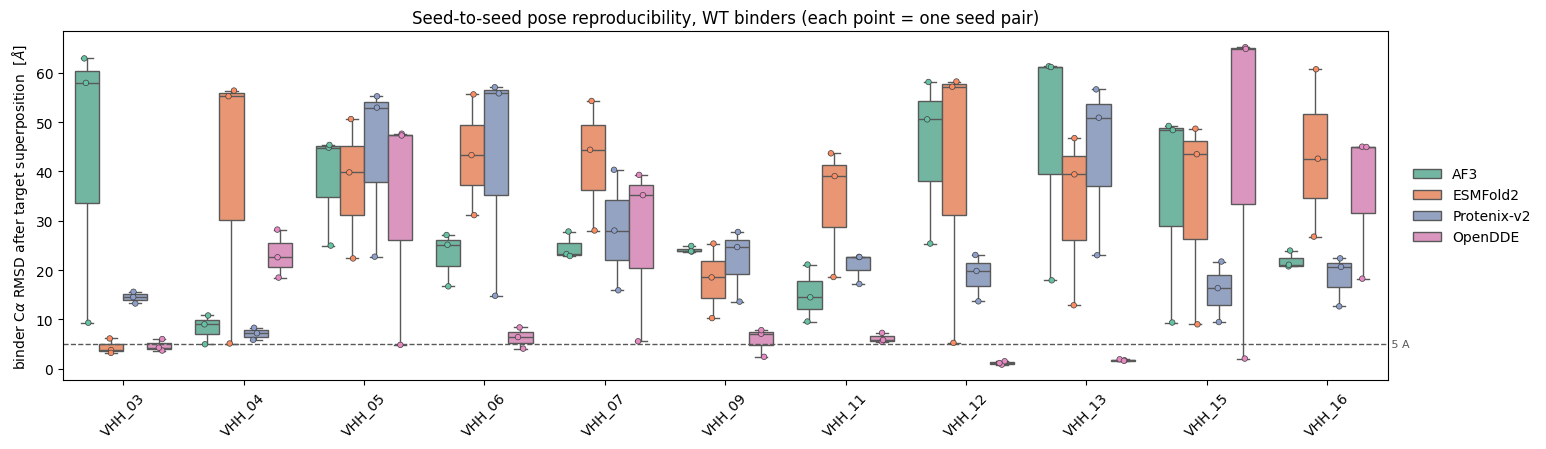

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/pose_reproducibility_WT_decoys.png


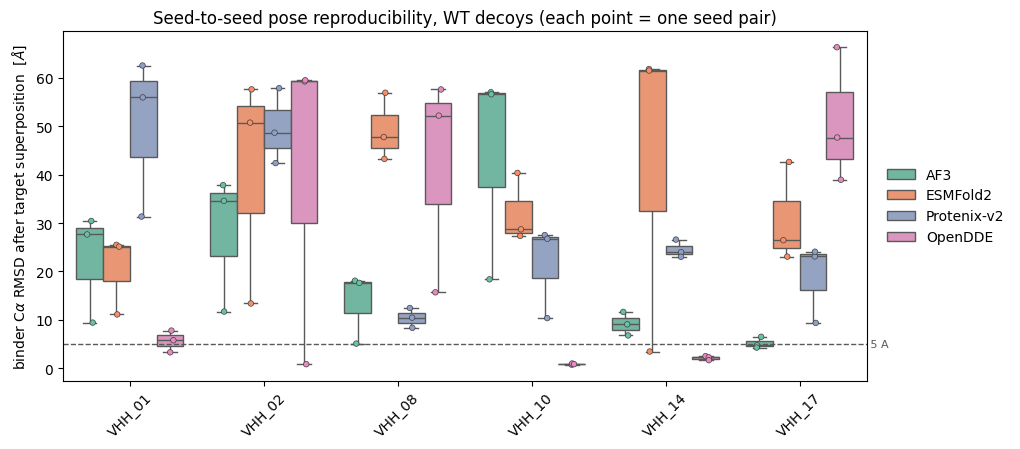

In [9]:
import itertools, glob, warnings
from Bio.PDB import MMCIFParser, Superimposer
warnings.filterwarnings("ignore")

RMSD_OK = 5.0                       # A, "same pose" threshold
_parser = MMCIFParser(QUIET=True)
# The target chain is always the longer of the two: IL-6 is 183 aa untrimmed or
# 163 trimmed, the VHH domains are 116-130. Identifying by length rather than by
# a hardcoded 183 keeps this working for models built from a trimmed target.

def model_files(mdir, target):
    """Model layout differs: ESMFold2 has models/ directly, others under output/."""
    for pat in (f"{mdir}/{target}/output/models/*.cif", f"{mdir}/{target}/models/*.cif"):
        g = sorted((WD / p).as_posix() for p in [])  # placeholder, see below
        g = sorted(glob.glob(str(WD / pat)))
        if g:
            return g
    return []

def target_binder_ca(path):
    st = _parser.get_structure("s", path)[0]
    cs = {c.id: [r for r in c if r.id[0] == " "] for c in st}
    tk = max(cs, key=lambda k: len(cs[k]))        # target = longer chain
    bk = [k for k in cs if k != tk][0]
    assert len(cs[tk]) > len(cs[bk]), f"ambiguous chains in {path}"
    ca = lambda rs: [r["CA"] for r in rs if "CA" in r]
    return ca(cs[tk]), ca(cs[bk])

# Every (target, design) pair, labelled binder/decoy FOR THAT TARGET. `labels`
# comes from section 7. A VHH is typically a binder on WT and a decoy on the
# mutants it flips on, so the same molecule appears in both classes.
cls_of = {(t, d): ("binder" if l == 1 else "decoy")
          for t, d, l in labels.itertuples(index=False)}
print("(target, design) pairs: " +
      ", ".join(f"{k} {v}" for k, v in
                pd.Series(list(cls_of.values())).value_counts().items()))

rows = []
for mdir, mname in MODELS.items():
    for target in TARGET_ORDER:
        files = model_files(mdir, target)
        for dsg in sorted({d for (t, d) in cls_of if t == target}):
            fs = [f for f in files if f"/{dsg}_" in f]
            if len(fs) < 2:
                continue
            pose = [target_binder_ca(f) for f in fs]
            for (t1, b1), (t2, b2) in itertools.combinations(pose, 2):
                sup = Superimposer()
                sup.set_atoms(t1, t2)             # align on the TARGET
                moved = [a.copy() for a in b2]
                sup.apply(moved)                  # carry the binder along
                n = min(len(b1), len(moved))
                rmsd = np.sqrt(np.mean([np.sum((b1[i].coord - moved[i].coord) ** 2)
                                        for i in range(n)]))
                rows.append(dict(model=mname, target=target, Design=dsg,
                                 cls=cls_of[(target, dsg)],
                                 target_rmsd=sup.rms, binder_rmsd=rmsd))

rms = pd.DataFrame(rows)
rms.to_csv(PRO / "pose_reproducibility_WT.csv", index=False)

wt = rms[rms.target == out_name(WT)]
summary = (wt.groupby(["model", "cls"])
              .agg(target_rmsd_med=("target_rmsd", "median"),
                   binder_rmsd_med=("binder_rmsd", "median"),
                   pct_under_5A=("binder_rmsd", lambda s: 100 * (s < RMSD_OK).mean()))
              .round(2))
print("\n" + summary.to_string())

ORDER = list(MODELS.values())
for cls in ["binder", "decoy"]:
    sub_ = wt[wt.cls == cls]
    designs = sorted(sub_.Design.unique())
    fig, ax = plt.subplots(figsize=(1.05 * len(designs) + 4, 4.6))
    sns.boxplot(data=sub_, x="Design", y="binder_rmsd", hue="model", order=designs,
                hue_order=ORDER, palette="Set2", showfliers=False, ax=ax)
    sns.stripplot(data=sub_, x="Design", y="binder_rmsd", hue="model", order=designs,
                  hue_order=ORDER, palette="Set2", dodge=True, size=4,
                  edgecolor="0.25", linewidth=0.5, legend=False, ax=ax)
    ax.axhline(RMSD_OK, ls="--", lw=1, color="0.35")
    ax.text(ax.get_xlim()[1], RMSD_OK, f" {RMSD_OK:g} A", va="center",
            fontsize=8, color="0.35")
    ax.set_ylabel("binder C$\\alpha$ RMSD after target superposition  [$\\AA$]")
    ax.set_xlabel("")
    ax.set_title(f"Seed-to-seed pose reproducibility, WT {cls}s "
                 f"(each point = one seed pair)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.tight_layout()
    out = WD / f"pose_reproducibility_WT_{cls}s.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"wrote {out}")
    plt.show()

## 9. Pose reproducibility by method, binder vs decoy

All four methods side by side. **One point = one target/VHH complex**, scored by
the *mean* of its 3 seed-to-seed RMSDs. Hue is that complex's label.

Per method this gives 18 binder and 31 decoy complexes (49 (design, target)
cells across the four targets). Lower is more reproducible, so the y-axis is
drawn with better at the top.

Unlike section 9 this is **unpaired** — binder and decoy complexes are pooled
across VHHs rather than compared within one. That is the weaker design (VHH
identity is no longer held fixed) but it is the one that answers "which method
separates the classes best", and it keeps all 49 complexes rather than the 17
VHHs that appear in both classes.

> The Mann-Whitney p-values below treat the 49 complexes as independent. They are
> not: one VHH contributes up to 4 complexes, and VHHs within a clonotype are
> related. Read the p-values as descriptive.

complexes per class, per method:
cls          binder  decoy
model                     
AF3              18     31
ESMFold2         18     31
OpenDDE          18     31
Protenix-v2      18     31

mean seed-to-seed RMSD [A] per complex:
                    size     median       mean
model       cls                               
AF3         binder    18  23.600000  26.400000
            decoy     31  28.100000  28.100000
ESMFold2    binder    18  36.299999  33.299999
            decoy     31  38.299999  33.599998
OpenDDE     binder    18  25.000000  22.700001
            decoy     31  21.799999  27.100000
Protenix-v2 binder    18  21.400000  26.700001
            decoy     31  23.700001  26.900000

AP (score = -mean_rmsd).  APbase = 0.37 (18/49)
  AF3           binder  23.6   decoy  28.1   AP = 0.38
  ESMFold2      binder  36.3   decoy  38.3   AP = 0.38
  Protenix-v2   binder  21.4   decoy  23.7   AP = 0.42
  OpenDDE       binder  25.0   decoy  21.8   AP = 0.46

wrote /Users/roessner/Do

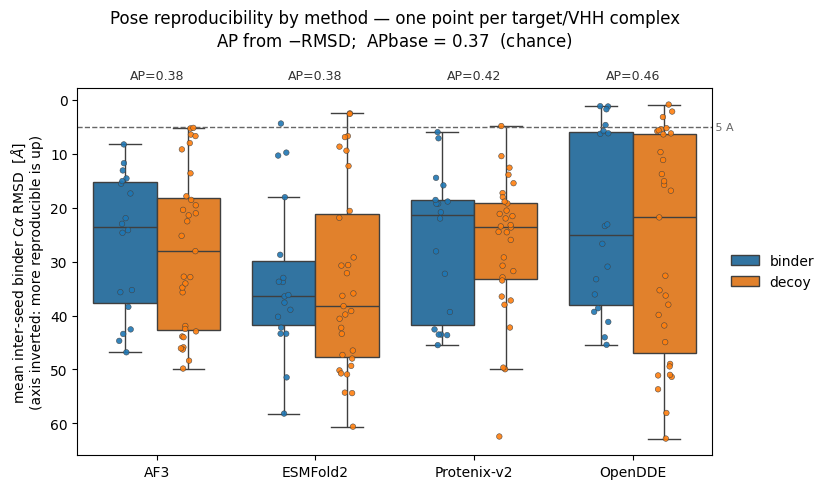

In [10]:
from sklearn.metrics import average_precision_score

# one point per (model, target, design): MEAN over that complex's 3 seed pairs
cx = (rms.groupby(["model", "target", "Design", "cls"]).binder_rmsd
         .mean().reset_index(name="mean_rmsd"))

print("complexes per class, per method:")
print(cx.pivot_table(index="model", columns="cls", values="mean_rmsd",
                     aggfunc="size").to_string())
print("\nmean seed-to-seed RMSD [A] per complex:")
print(cx.groupby(["model", "cls"]).mean_rmsd
        .agg(["size", "median", "mean"]).round(1).to_string())

# AP with the score INVERTED: low RMSD is binder-like, AP assumes higher = positive.
cx["label"] = (cx.cls == "binder").astype(int)
AP_BASE = cx.groupby("model").label.mean().iloc[0]      # identical for every model
print(f"\nAP (score = -mean_rmsd).  APbase = {AP_BASE:.2f} "
      f"({int(cx.label.sum() / cx.model.nunique())}/{len(cx) // cx.model.nunique()})")
stats = {}
for m in MODELS.values():
    g = cx[cx.model == m]
    stats[m] = average_precision_score(g.label, -g.mean_rmsd)
    a = g.loc[g.cls == "binder", "mean_rmsd"]; b = g.loc[g.cls == "decoy", "mean_rmsd"]
    print(f"  {m:<13} binder {a.median():>5.1f}   decoy {b.median():>5.1f}   "
          f"AP = {stats[m]:.2f}")

PAL = {"binder": "#1f77b4", "decoy": "#ff7f0e"}
ORDER = list(MODELS.values())
fig, ax = plt.subplots(figsize=(8.4, 5.0))
sns.boxplot(data=cx, x="model", y="mean_rmsd", hue="cls", order=ORDER,
            hue_order=["binder", "decoy"], palette=PAL, showfliers=False, ax=ax)
sns.stripplot(data=cx, x="model", y="mean_rmsd", hue="cls", order=ORDER,
              hue_order=["binder", "decoy"], palette=PAL, dodge=True, size=4,
              edgecolor="0.25", linewidth=0.4, alpha=0.9, legend=False, ax=ax)
ax.axhline(RMSD_OK, ls="--", lw=1, color="0.4")
ax.text(ax.get_xlim()[1], RMSD_OK, f" {RMSD_OK:g} A", va="center",
        fontsize=8, color="0.4")
for i, m in enumerate(ORDER):
    ax.text(i, 1.015, f"AP={stats[m]:.2f}", ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontsize=9, color="0.2")
ax.invert_yaxis()                      # better (lower RMSD) at the top
ax.set_ylabel("mean inter-seed binder C$\\alpha$ RMSD  [$\\AA$]\n(axis inverted: "
              "more reproducible is up)")
ax.set_xlabel("")
ax.set_title("Pose reproducibility by method — one point per target/VHH complex\n"
             f"AP from $-$RMSD;  APbase = {AP_BASE:.2f}  (chance)", pad=30)
ax.legend(title="", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
out = WD / "pose_reproducibility_by_method.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"\nwrote {out}")
plt.show()

## 10. Same view, scored by ipTM

Section 9 with the metric swapped: **ipTM instead of pose reproducibility**, same
unit (one point per target/VHH complex, averaged over its 3 seeds), same layout,
same `APbase`. Directly comparable to section 9 — the question is whether either
quantity separates the classes, and which does it better.

Two differences from section 9, both because ipTM is a *similarity*:

* the score is **not negated** for AP (higher ipTM = more binder-like, whereas
  lower RMSD was);
* the y-axis is **not inverted** (better is already up).

ipTM ranges differ a lot between methods — AF3 sits near 0.1-0.25, OpenDDE near
0.2-0.9 — so the panels are not on a common scale. That does not affect AP, which
is rank-based and computed within each method.

complexes per class, per method:
class        binder  decoy
model                     
AF3              18     31
ESMFold2         18     31
OpenDDE          18     31
Protenix-v2      18     31

seed-averaged ipTM per complex:
                    size  median   mean
model       class                      
AF3         binder    18   0.130  0.135
            decoy     31   0.130  0.137
ESMFold2    binder    18   0.187  0.239
            decoy     31   0.204  0.225
OpenDDE     binder    18   0.274  0.386
            decoy     31   0.308  0.401
Protenix-v2 binder    18   0.282  0.300
            decoy     31   0.272  0.293

AP (score = +ipTM).  APbase = 0.37
  AF3           binder  0.130   decoy  0.130   AP = 0.39
  ESMFold2      binder  0.187   decoy  0.204   AP = 0.41
  Protenix-v2   binder  0.282   decoy  0.272   AP = 0.42
  OpenDDE       binder  0.274   decoy  0.308   AP = 0.42



wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/iptm_by_method.png


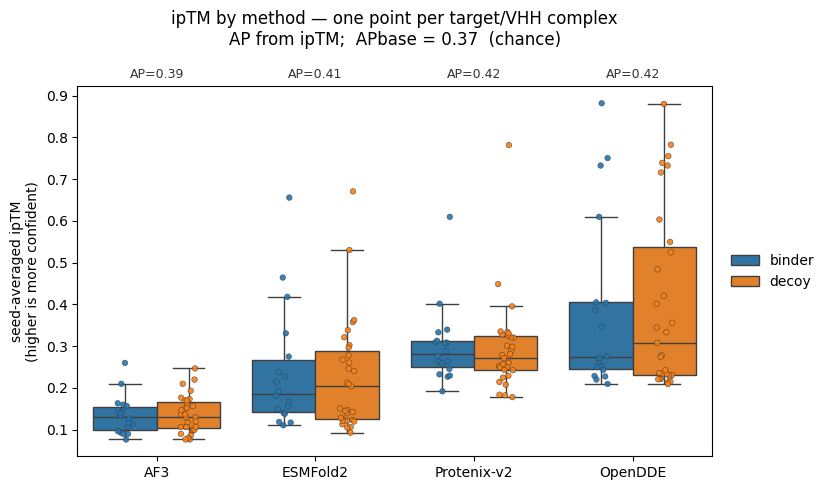

In [11]:
# Read section 7's scored table from disk rather than relying on `pred` still
# being in memory, so this cell works after a kernel restart.
ipt = (pd.read_csv(PRO / "predictions_iptm.csv")
         .rename(columns={"score": "iptm"}))

print("complexes per class, per method:")
print(ipt.pivot_table(index="model", columns="class", values="iptm",
                      aggfunc="size").to_string())
print("\nseed-averaged ipTM per complex:")
print(ipt.groupby(["model", "class"]).iptm
         .agg(["size", "median", "mean"]).round(3).to_string())

# AP: ipTM is a similarity, so NO negation here (section 9 negated RMSD).
AP_BASE_I = ipt.groupby("model").label.mean().iloc[0]
print(f"\nAP (score = +ipTM).  APbase = {AP_BASE_I:.2f}")
ap_i = {}
for m in MODELS.values():
    g = ipt[ipt.model == m]
    ap_i[m] = average_precision_score(g.label, g.iptm)
    a = g.loc[g["class"] == "binder", "iptm"]; b = g.loc[g["class"] == "decoy", "iptm"]
    print(f"  {m:<13} binder {a.median():>6.3f}   decoy {b.median():>6.3f}   "
          f"AP = {ap_i[m]:.2f}")

PAL = {"binder": "#1f77b4", "decoy": "#ff7f0e"}
ORDER = list(MODELS.values())
fig, ax = plt.subplots(figsize=(8.4, 5.0))
sns.boxplot(data=ipt, x="model", y="iptm", hue="class", order=ORDER,
            hue_order=["binder", "decoy"], palette=PAL, showfliers=False, ax=ax)
sns.stripplot(data=ipt, x="model", y="iptm", hue="class", order=ORDER,
              hue_order=["binder", "decoy"], palette=PAL, dodge=True, size=4,
              edgecolor="0.25", linewidth=0.4, alpha=0.9, legend=False, ax=ax)
for i, m in enumerate(ORDER):
    ax.text(i, 1.015, f"AP={ap_i[m]:.2f}", ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontsize=9, color="0.2")
ax.set_ylabel("seed-averaged ipTM\n(higher is more confident)")
ax.set_xlabel("")
ax.set_title("ipTM by method — one point per target/VHH complex\n"
             f"AP from ipTM;  APbase = {AP_BASE_I:.2f}  (chance)", pad=30)
ax.legend(title="", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.tight_layout()
out = WD / "iptm_by_method.png"
fig.savefig(out, dpi=200, bbox_inches="tight")
print(f"\nwrote {out}")
plt.show()

## 11. Pose-reproducibility table (OpenDDE)

One row per VHH, one column per target. The value is the **minimum** inter-seed
RMSD for that complex — the best agreement any two of its three seeds reached.
`N/A` means the VHH was never assayed against that target, so no model was run.

Cells are coloured by that complex's label: **blue = binder**, **orange = decoy**.
Colour saturation tracks the RMSD, so a strongly coloured cell is a converged
pose and a pale one is not.

> `min` is used here deliberately, and it is not the statistic sections 9-10 use.
> It answers "did *any* two seeds agree", which is the right question when the
> goal is to obtain one usable starting pose for a simulation. Sections 9-10 use
> the median, which answers "does the typical pair agree" — the right question
> when scoring a method. The two disagree in 35 of 196 cells, where two seeds
> converge and the third diverges.

In [12]:
POSE_MODEL = "OpenDDE"

rep = pd.read_csv(PRO / "pose_reproducibility_WT.csv")
rep = rep[rep.model == POSE_MODEL]
assert len(rep), f"no rows for {POSE_MODEL}"

cols = [t for t in TARGET_ORDER if t in set(rep.target)]
vals = (rep.pivot_table(index="Design", columns="target",
                        values="binder_rmsd", aggfunc="min")
           .reindex(columns=cols).sort_index())
klass = (rep.drop_duplicates(["Design", "target"])
            .pivot(index="Design", columns="target", values="cls")
            .reindex(columns=cols).reindex(index=vals.index))

n_cells = int(vals.notna().sum().sum())
print(f"{POSE_MODEL}: min inter-seed RMSD [A] — {len(vals)} VHHs x {len(cols)} targets, "
      f"{n_cells} complexes, {vals.size - n_cells} N/A")
print(f"binder cells {int((klass == 'binder').sum().sum())}, "
      f"decoy cells {int((klass == 'decoy').sum().sum())}")
print(f"complexes with min < {RMSD_OK:g} A: "
      f"{int((vals < RMSD_OK).sum().sum())}/{n_cells}")

# blue = binder, orange = decoy; saturation falls off as RMSD rises
VMAX = 30.0
def shade(v, c):
    if pd.isna(v) or pd.isna(c):
        return "background-color: #f2f2f2; color: #999"
    a = 0.12 + 0.68 * (1 - min(v, VMAX) / VMAX)          # 0.12 (poor) .. 0.80 (tight)
    rgb = (31, 119, 180) if c == "binder" else (255, 127, 14)
    fg = "#ffffff" if a > 0.55 else "#111111"
    return f"background-color: rgba({rgb[0]},{rgb[1]},{rgb[2]},{a:.2f}); color: {fg}"

styled = (vals.style
              .apply(lambda col: [shade(v, klass.loc[i, col.name])
                                  for i, v in col.items()], axis=0)
              .format(lambda v: "N/A" if pd.isna(v) else f"{v:.1f}")
              .set_caption(f"{POSE_MODEL} — min inter-seed binder RMSD [Å]; "
                           f"blue = binder, orange = decoy, N/A = not assayed")
              .set_table_styles([
                  {"selector": "caption",
                   "props": [("caption-side", "top"), ("font-size", "11pt"),
                             ("padding-bottom", "6px")]},
                  {"selector": "th", "props": [("font-size", "10pt")]},
                  {"selector": "td", "props": [("text-align", "center"),
                                               ("min-width", "72px")]}]))

out = WD / f"pose_table_{POSE_MODEL}.html"
out.write_text(styled.to_html())
vals.to_csv(PRO / f"pose_min_rmsd_{POSE_MODEL}.csv")
print(f"\nwrote {out}")
print(f"wrote {PRO / f'pose_min_rmsd_{POSE_MODEL}.csv'}")
styled

OpenDDE: min inter-seed RMSD [A] — 17 VHHs x 4 targets, 49 complexes, 19 N/A
binder cells 18, decoy cells 31
complexes with min < 5 A: 26/49

wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/pose_table_OpenDDE.html
wrote /Users/roessner/Documents/PostDoc/Data/261003_MD_single_interface_mutations/data/processed/pose_min_rmsd_OpenDDE.csv


target,IL-6_WT,IL-6_F102A,IL-6_E138A,IL-6_F153A
Design,,,,
VHH_01,3.3,N/A,N/A,18.7
VHH_02,0.8,30.8,N/A,N/A
VHH_03,3.7,N/A,12.7,6.9
VHH_04,18.5,33.0,N/A,N/A
VHH_05,4.8,36.4,22.1,16.6
VHH_06,4.1,3.9,N/A,N/A
VHH_07,5.6,32.8,57.1,2.0
VHH_08,15.7,N/A,19.7,N/A
VHH_09,2.4,2.4,2.6,4.0
